In [3]:
import pandas as pd
pd.set_option('display.max_colwidth', None) #setting the max col width to see the whole text
df = pd.read_csv("IMDB Dataset.csv")
df.head(2)

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive


In [7]:
#checking the class balance
# Count labels
label_counts = df["sentiment"].value_counts()
label_perc = df["sentiment"].value_counts(normalize=True) * 100

print("Class counts:\n", label_counts)
print("\nClass percentages:\n", label_perc.round(2))

Class counts:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Class percentages:
 sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [15]:
#lets check the missing values and if any row has empty reviews
# Check missing values
print("Missing reviews:", df["review"].isna().sum())
print("Missing sentiments:", df["sentiment"].isna().sum())

# Check empty/blank reviews
empty_reviews = (df["review"].astype(str).str.strip() == "").sum()
print("Empty reviews:", empty_reviews)

Missing reviews: 0
Missing sentiments: 0
Empty reviews: 0


In [16]:
# Character length of reviews to see how many charecters are in our reviews.
#this is helpful to detect extremely large reviews that may slow training
df["char_len"] = df["review"].astype(str).str.len()
print("Character length summary:")
print(df["char_len"].describe())

Character length summary:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: char_len, dtype: float64


In [26]:
 # Word count length of reviews to see how many words or tokens are there in our reviews
#this and the above steps are necessary to do the padding/truncating if the token number is exceeded, because LSTMs have memory limits
df["word_len"] = df["review"].astype(str).str.split().apply(len)
print("\nWord length summary:")
print(df["word_len"].describe())


Word length summary:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_len, dtype: float64


In [33]:
#Lets clean the data now, lets define a cleaning function
import re

def clean_review(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r"<.*?>", " ", text) # Remove HTML tags like <br />
    text = re.sub(r"http\S+|www\S+", " ", text) # Remove URLs (http, https, www)
    text = re.sub(r"[^a-z\s]", " ", text) # Remove punctuation and digits (keep only letters and spaces)
    text = re.sub(r"\s+", " ", text).strip() # Remove extra spaces
    return text

In [35]:
# Apply cleaning function to all reviews
df["clean_review"] = df["review"].apply(clean_review)

In [36]:
df[["review", "clean_review"]].head(5)

,review,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldn t dare forget pretty pictures painted for mainstream audiences forget charm forget romance oz doesn t mess around the first episode i ever saw struck me as so nasty it was surreal i couldn t say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards who ll be sold out for a nickel inmates who ll kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewing thats if you can get in touch with your darker side
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A master

In [42]:
#checking if any cleaned reviews has become empty
#Checking if any cleaned reviews became empty
empty_clean_reviews = (df["clean_review"].str.strip() == "").sum()
print("Empty cleaned reviews:", empty_clean_reviews)

Empty cleaned reviews: 0


In [46]:
#Checking length again after cleaning
df["clean_word_len"] = df["clean_review"].str.split().apply(len)
df["clean_word_len"].describe()

count    50000.000000
mean       234.162560
std        173.504852
min          6.000000
25%        128.000000
50%        176.000000
75%        284.000000
max       2494.000000
Name: clean_word_len, dtype: float64

In [50]:
#Lets give the labeling now, positive/negative --> 1/0 to the sentiment column
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0}).astype(int)
df[["sentiment", "label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [51]:
#lets do the training/validation/test split as 80/10/10

In [59]:
import numpy as np
from sklearn.model_selection import train_test_split
X = df["clean_review"].astype(str).to_numpy()
y = df["label"].astype(int).to_numpy()

#First split: 80% train, 20% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
#Second split: split the above 20% into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, #here test size is 0.50 because we are splitting the 20% half and half
    random_state=42,
    stratify=y_temp #keeps 50/50 positive/negative in both sets
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
print("Train pos%:", round(y_train.mean()*100, 2),
      "Val pos%:", round(y_val.mean()*100, 2),
      "Test pos%:", round(y_test.mean()*100, 2))

Train: 40000 Val: 5000 Test: 5000
Train pos%: 50.0 Val pos%: 50.0 Test pos%: 50.0


In [62]:
#lets tokenize and buid some vocabulary here
from tensorflow.keras.preprocessing.text import Tokenizer

#20,000 is a standard good size for IMDB
VOCAB_SIZE = 20000 #we are keeping only the 20,000 most frequent words, ignoring the rest to reduce memory and noise

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>") #here OOV is out of vocab, if the tokenizer sees a word it doesnt know, it replaces it with <OOV>, whose value is 1 as a token.
tokenizer.fit_on_texts(X_train)

#now lets convert texts to sequences of integers
train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)
test_seq  = tokenizer.texts_to_sequences(X_test)

print("Example cleaned review:\n", X_train[0][:300])
print("\nTokenized sequence (first 30 ids):\n", train_seq[0][:30])
print("\nActual vocabulary size learned:", len(tokenizer.word_index))
print("Tokenizer vocab cap (num_words):", VOCAB_SIZE)

Example cleaned review:
 i caught this little gem totally by accident back in or i was at a revival theatre to see two old silly sci fi movies the theatre was packed full and with no warning they showed a bunch of sci fi short spoofs to get us in the mood most were somewhat amusing but this came on and within seconds the au

Tokenized sequence (first 30 ids):
 [10, 1031, 11, 121, 1480, 453, 34, 1592, 145, 9, 41, 10, 14, 32, 4, 8620, 1636, 6, 66, 107, 159, 660, 854, 846, 98, 2, 1636, 14, 2800, 357]

Actual vocabulary size learned: 90384
Tokenizer vocab cap (num_words): 20000


In [65]:
#since our median value is 176, a safe value is 250 tokens
#we are padding here, with the max length 250, that means if the review is shorter than 250 tokens, it will add 0 in the end
#if the review is longer than 250 tokens, padding cuts the number after 250 tokens.
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_LEN = 250  #we can try 200 or 300 later if we want the comparison

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Padded train shape:", X_train_pad.shape)
print("Padded val shape  :", X_val_pad.shape)
print("Padded test shape :", X_test_pad.shape)

Padded train shape: (40000, 250)
Padded val shape  : (5000, 250)
Padded test shape : (5000, 250)


In [67]:
import gensim
import numpy as np

# Path to the Google News Word2Vec binary file
W2V_PATH = "GoogleNews-vectors-negative300.bin" #download this file in your path, and load it, this is a pretrained model that will change your tokens into numbers
word2vec = gensim.models.KeyedVectors.load_word2vec_format(
    W2V_PATH,
    binary=True
)
print("Word2Vec loaded!")
print("Vector size:", word2vec.vector_size)

Word2Vec loaded!
Vector size: 300


In [71]:
#lets create an embedding matrix now
#we already know our parameters size
VOCAB_SIZE = 20000
EMBEDDING_DIM = 300

#lets initialize the embedding matrix with some random values
#the shape would be (vocab_size + 1, embedding_dim)
embedding_matrix = np.random.normal(
    scale=0.6,
    size=(VOCAB_SIZE + 1, EMBEDDING_DIM) #here +1 is beacause index 0 is reserved for the padding
)
#lets fill embedding matrix with pretrained vectors where available
hits = 0   # words found in Word2Vec
misses = 0 # OOV words

for word, index in tokenizer.word_index.items():
    if index > VOCAB_SIZE:  # Skip words outside vocab size
        continue
    if word in word2vec: #if Word2Vec knows the word, then we use its pretrained vector
        embedding_matrix[index] = word2vec[word]
        hits += 1
    else:
        # Word not found, then keep random vector
        misses += 1

print(f"Words found in Word2Vec: {hits}")
print(f"Words NOT found (OOV): {misses}")
print(f"Coverage: {hits / (hits + misses) * 100:.2f}%")

Words found in Word2Vec: 17986
Words NOT found (OOV): 2014
Coverage: 89.93%


In [ ]:
#now lets create the embedding layer.
#we can use two ways, we can froze the embeddings first, then we will train the embeddings

In [79]:
#froze the embeddings first
from tensorflow.keras.layers import Embedding

embedding_layer_frozen = Embedding(
    input_dim=VOCAB_SIZE + 1,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=250,
    trainable=False   #embeddings are frozen here
)

In [84]:
#trainable embeddings here
embedding_layer_trainable = Embedding(
    input_dim=VOCAB_SIZE + 1,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=250,
    trainable=True
)

In [92]:
#lets build the model with the frozen embeddings first
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42) #this is purely optional, but for reproducibility reasons we are using the seed here

#lets build a baseline LSTM model
model_frozen = Sequential([
    #embedding layer initialized with pretrained Word2Vec
    embedding_layer_frozen, #trainable=False means embeddings are frozen (not updated during training)

    #Bidirectional LSTM reads the sequence left-to-right and right-to-left, this improves sentiment performance because context matters both ways
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5), #dropout helps reduce overfitting
    Dense(64, activation="relu"),  #dense layer to learn final decision boundary
    Dropout(0.3),
    Dense(1, activation="sigmoid") #1 neuron with sigmoid for binary classification, and this is for the output layer
])

#lets compile the model
#we are using the Binary crossentropy is correct for binary classification
#also Adam is a strong default optimizer
model_frozen.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
model_frozen.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │       6,000,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_7 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,000,300 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,300 (22.89 MB)

In [93]:
#lets train the model now
#we are earlyStopping here because to stop training if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau( #if val_loss plateaus, reduce learning rate automatically
    monitor="val_loss",
    factor=0.5,
    patience=1,
    verbose=1
)
history_frozen = model_frozen.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=6,            # lets start small, we can increase later. And Frozen embeddings often converge quickly, if it’s underfitting, we can increase later
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 200s 618ms/step - accuracy: 0.7003 - loss: 0.5670 - val_accuracy: 0.8134 - val_loss: 0.4309 - learning_rate: 0.0010
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 173s 552ms/step - accuracy: 0.8023 - loss: 0.4479 - val_accuracy: 0.8244 - val_loss: 0.3908 - learning_rate: 0.0010
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 171s 546ms/step - accuracy: 0.7944 - loss: 0.4527 - val_accuracy: 0.8344 - val_loss: 0.3755 - learning_rate: 0.0010
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.8337 - loss: 0.3934
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 170s 542ms/step - accuracy: 0.8377 - loss: 0.3891 - val_accuracy: 0.8034 - val_loss: 0.4147 - learning_rate: 0.0010
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 173s 554ms/step - accuracy: 0.8544 - loss: 0.3471 - val_accuracy: 0.8340 - val_loss: 0.3659 - learning_rate: 5.0000e-04
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 175s 559ms/step - accuracy: 0

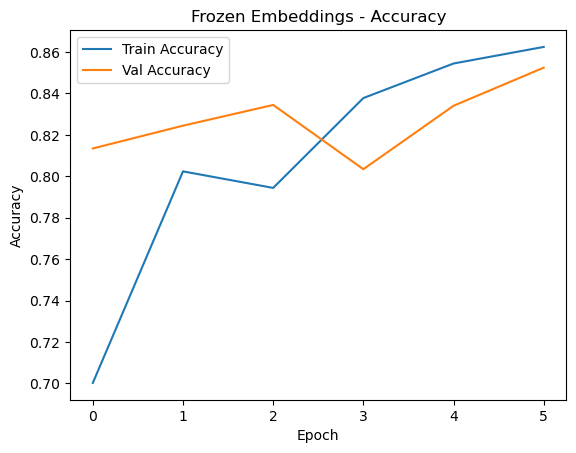

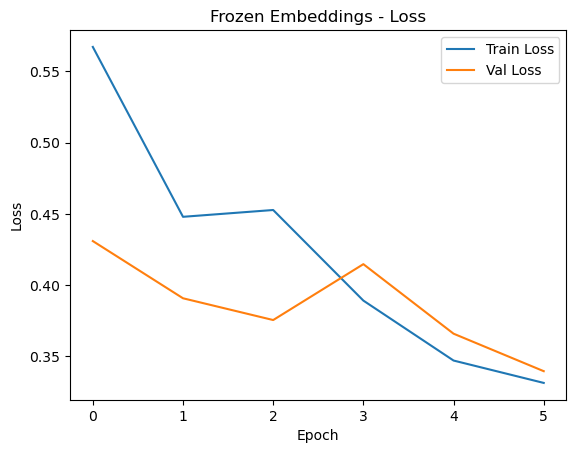

In [97]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history_frozen.history["accuracy"], label="Train Accuracy")
plt.plot(history_frozen.history["val_accuracy"], label="Val Accuracy")
plt.title("Frozen Embeddings - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.plot(history_frozen.history["loss"], label="Train Loss")
plt.plot(history_frozen.history["val_loss"], label="Val Loss")
plt.title("Frozen Embeddings - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [101]:
#lets create the evaluation metrics for the frozen model first
import numpy as np

#predicted probabilities (between 0 and 1)
y_prob_frozen = model_frozen.predict(X_test_pad, batch_size=256).ravel()

#lets convert probabilities to class labels using 0.5 threshold
y_pred_frozen = (y_prob_frozen >= 0.5).astype(int)

print("Sample probs:", y_prob_frozen[:10])
print("Sample preds:", y_pred_frozen[:10])

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step
Sample probs: [0.70716447 0.7875133  0.5709572  0.04083323 0.84086394 0.01718135
 0.7753942  0.08182551 0.9133358  0.21750727]
Sample preds: [1 1 1 0 1 0 1 0 1 0]


In [154]:
#Accuracy, Precision, Recall, F1, ROC-AUC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
fr_acc  = accuracy_score(y_test, y_pred_frozen) #accuracy
fr_prec = precision_score(y_test, y_pred_frozen) #precision
fr_rec  = recall_score(y_test, y_pred_frozen) #recall
fr_f1   = f1_score(y_test, y_pred_frozen) #f1
fr_auc  = roc_auc_score(y_test, y_prob_frozen) #AUC curve

print(f"Frozen LSTM Test Accuracy : {fr_acc:.4f}")
print(f"Frozen LSTM Test Precision: {fr_prec:.4f}")
print(f"Frozen LSTM Test Recall   : {fr_rec:.4f}")
print(f"Frozen LSTM Test F1-score : {fr_f1:.4f}")
print(f"Frozen LSTM Test ROC-AUC  : {fr_auc:.4f}")

Frozen LSTM Test Accuracy : 0.8540
Frozen LSTM Test Precision: 0.8235
Frozen LSTM Test Recall   : 0.9012
Frozen LSTM Test F1-score : 0.8606
Frozen LSTM Test ROC-AUC  : 0.9305


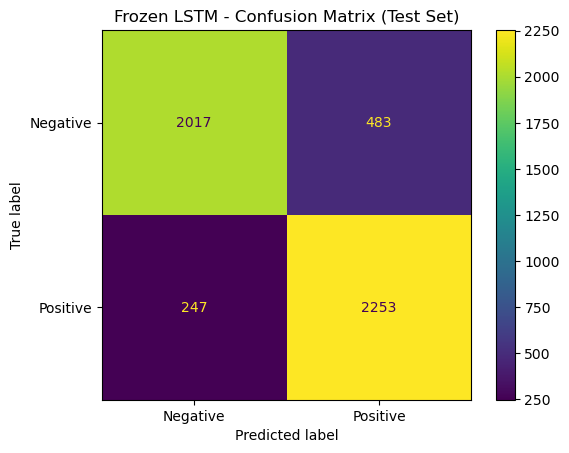

In [156]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_frozen)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(values_format="d")
plt.title("Frozen LSTM - Confusion Matrix (Test Set)")
plt.show()

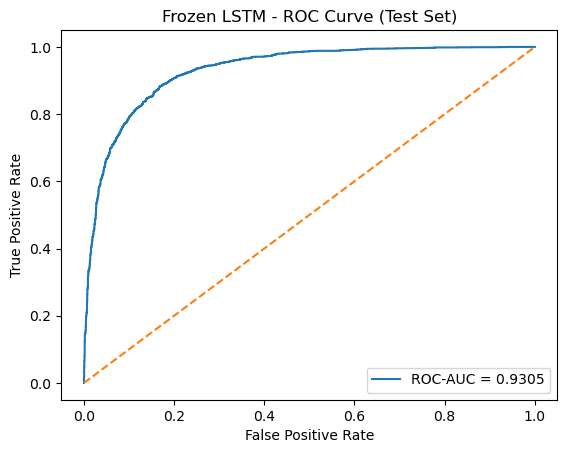

In [157]:
#ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_frozen)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {fr_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Frozen LSTM - ROC Curve (Test Set)")
plt.legend()
plt.show()

In [158]:
# Get indices of misclassifications
#we are pulling all cases where the prediction is not equal to truth
fp_idx = np.where((y_pred_frozen == 1) & (y_test == 0))[0]  # predicted pos, actual neg
fn_idx = np.where((y_pred_frozen == 0) & (y_test == 1))[0]  # predicted neg, actual pos
print("False Positives:", len(fp_idx))
print("False Negatives:", len(fn_idx))

# Pick 5 examples each
fp_examples = fp_idx[:5]
fn_examples = fn_idx[:5]

print("\n--- 5 False Positives (pred=Positive, actual=Negative) ---")
for i in fp_examples:
    print(f"\nProb={y_prob_frozen[i]:.4f} | Actual={y_test[i]} | Pred={y_pred_frozen[i]}")
    print(X_test[i][:500])  # show first 500 chars

print("\n--- 5 False Negatives (pred=Negative, actual=Positive) ---")
for i in fn_examples:
    print(f"\nProb={y_prob_frozen[i]:.4f} | Actual={y_test[i]} | Pred={y_pred_frozen[i]}")
    print(X_test[i][:500])

False Positives: 483
False Negatives: 247

--- 5 False Positives (pred=Positive, actual=Negative) ---

Prob=0.7072 | Actual=0 | Pred=1
although it has been years i still remember the complete waste that comprises the entire plot of the movie unfortunately i came across this movie after my friends and i selected it while browsing through the new releases at blockbuster we decided to pick the movie because it was the only one we all had not seen and it sounded like it may be enjoyable although it has been quite some time since i viewed the movie i still remember the lack of plot seriously there is no true plot and complete waste 

Prob=0.8409 | Actual=0 | Pred=1
this is a film that has garnered any interest or praise it has received simply on the merit of being a lesbian interest piece the performances are mostly emotionless compared to better films in the glbt interest genre the entirety of the film s watchable value is garnered through modest suspense over whether and when the partners

In [160]:
#lets build the mdoel architecture of the trainable embeddings
#the process is the same
#we created the embedding_layer_trainable above, so lets use it here
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
model_trainable = Sequential([ #we are building a stacked model here, from top to bottom
    embedding_layer_trainable,
    Bidirectional(LSTM(64, return_sequences=False)), #each direction has 64 neurons
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
# Slightly smaller learning rate helps when fine-tuning embeddings
model_trainable.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4), #here we used low learning rate, because we dont want to spoil the pretrained vectors too quickly
    metrics=["accuracy"]
)
model_trainable.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)             │ (None, 250, 300)            │       6,000,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_12 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,000,300 (22.89 MB)

 Trainable params: 6,000,300 (22.89 MB)

 Non-trainable params: 0 (0.00 B)

In [161]:
#train the model with embedding_layer_trainable
#same as what we did above
#learning the val_accuracy and val_loss, but this time, this is trainable model, not frozen
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    verbose=1
)
history_trainable = model_trainable.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=6,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 292s 908ms/step - accuracy: 0.6710 - loss: 0.5627 - val_accuracy: 0.8712 - val_loss: 0.3342 - learning_rate: 2.0000e-04
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.8977 - loss: 0.2825
Epoch 2: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
313/313 ━━━━━━━━━━━━━━━━━━━━ 267s 852ms/step - accuracy: 0.9058 - loss: 0.2602 - val_accuracy: 0.8646 - val_loss: 0.3567 - learning_rate: 2.0000e-04
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 267s 854ms/step - accuracy: 0.9333 - loss: 0.1979 - val_accuracy: 0.8854 - val_loss: 0.3144 - learning_rate: 1.0000e-04
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 851ms/step - accuracy: 0.9367 - loss: 0.1912
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
313/313 ━━━━━━━━━━━━━━━━━━━━ 272s 868ms/step - accuracy: 0.9426 - loss: 0.1783 - val_accuracy: 0.8854 - val_loss: 0.3324 - learning_rate: 1.0000e-04
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - acc

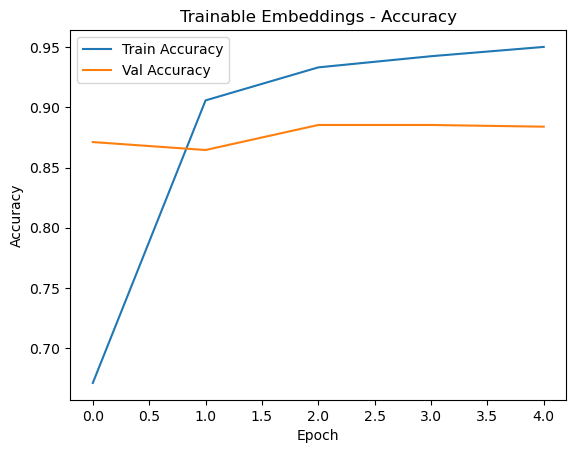

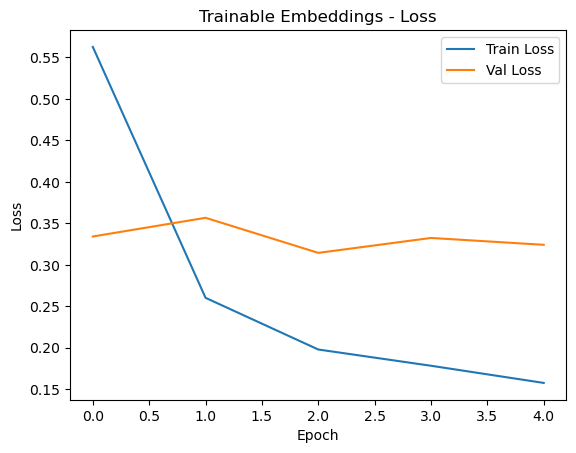

In [162]:
plt.figure()
plt.plot(history_trainable.history["accuracy"], label="Train Accuracy")
plt.plot(history_trainable.history["val_accuracy"], label="Val Accuracy")
plt.title("Trainable Embeddings - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_trainable.history["loss"], label="Train Loss")
plt.plot(history_trainable.history["val_loss"], label="Val Loss")
plt.title("Trainable Embeddings - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [163]:
# Predict probabilities on test set
y_test_probs_trainable = model_trainable.predict(X_test_pad).ravel()

# Convert probabilities to binary predictions
y_test_preds_trainable = (y_test_probs_trainable >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_test_preds_trainable)
prec = precision_score(y_test, y_test_preds_trainable)
rec = recall_score(y_test, y_test_preds_trainable)
f1 = f1_score(y_test, y_test_preds_trainable)
roc = roc_auc_score(y_test, y_test_probs_trainable)

print("Trainable LSTM Test Accuracy :", round(acc, 4))
print("Trainable LSTM Test Precision:", round(prec, 4))
print("Trainable LSTM Test Recall   :", round(rec, 4))
print("Trainable LSTM Test F1-score :", round(f1, 4))
print("Trainable LSTM Test ROC-AUC  :", round(roc, 4))

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step
Trainable LSTM Test Accuracy : 0.8906
Trainable LSTM Test Precision: 0.8886
Trainable LSTM Test Recall   : 0.8932
Trainable LSTM Test F1-score : 0.8909
Trainable LSTM Test ROC-AUC  : 0.9503


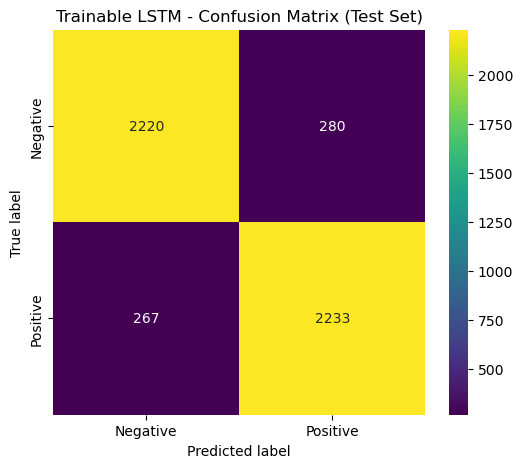

In [164]:
# Compute confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_test_preds_trainable)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Trainable LSTM - Confusion Matrix (Test Set)")
plt.show()

In [165]:
#false positives and false negatives of the trainable model
false_pos = np.where((y_test_preds_trainable == 1) & (y_test == 0))[0]
false_neg = np.where((y_test_preds_trainable == 0) & (y_test == 1))[0]

print("\n--- 5 False Positives (pred=Positive, actual=Negative) ---")
for idx in false_pos[:5]:
    print(f"Prob={y_test_probs_trainable[idx]:.3f} | Actual=0 | Pred=1")
    print(df.iloc[idx]["clean_review"][:300], "\n")

print("\n--- 5 False Negatives (pred=Negative, actual=Positive) ---")
for idx in false_neg[:5]:
    print(f"Prob={y_test_probs_trainable[idx]:.3f} | Actual=1 | Pred=0")
    print(df.iloc[idx]["clean_review"][:300], "\n")


--- 5 False Positives (pred=Positive, actual=Negative) ---
Prob=0.956 | Actual=0 | Pred=1
preston sturgis the power and the glory was unseen by the public for nearly twenty or thirty years until the late s when it resurfaced and even showed up on television in the meantime it had gained in notoriety because pauline kael s the citizen kane book had suggested that the herman mankiewicz ors 

Prob=0.990 | Actual=0 | Pred=1
an unmarried woman named stella bette midler gets pregnant by a wealthy man stephen collins he offers to marry her out of a sense of obligation but she turns him down flat and decides to raise the kid on her own things go ok until the child named jenny trini alvarado becomes a teenager and things gr 

Prob=0.845 | Actual=0 | Pred=1
oh noes one of these attack of the japanese ghost girl movies i don t even remember how many i ve seen maybe it sells but not to me not scary at all the japanese horror movies are have been very similar since the first one of these also the 

In [168]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Frozen Embeddings LSTM",
        "Trainable Embeddings LSTM"
    ],
    "Accuracy": [
        fr_acc,
        acc
    ],
    "Precision": [
        fr_prec,
        prec
    ],
    "Recall": [
        fr_rec,
        rec
    ],
    "F1-score": [
        fr_f1,
        f1
    ],
    "ROC-AUC": [
        fr_auc,
        roc
    ]
})
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Frozen Embeddings LSTM,0.8540,0.823465,0.9012,0.860581,0.930468
1,Trainable Embeddings LSTM,0.8906,0.888579,0.8932,0.890884,0.950251


In [ ]:
#Did the LSTM improve performance compared to the ANN-based classifier?
#I would say YES, but in a different and menanigful way. ANN with TF-IDF achieved high accuracy on the SMS Spam dataset, while IMDB with Word2Vec achieved lower accuracy, but it had much more data in it comaored to the Spam dataset.
#What differences did you notice between frozen vs trainable embeddings?
#there was a clear improvement when embeddings were made trainable, the accuaracy of frozen is ~85.4%, while the trainable is ~89.1%. In trainable we saw there is faster learning after the first epoch.